# <span style="color:green"> Lecture 01 notebook </span>

In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import chi2

## <span style="color:blue">  Exercise 01.1 </span>

Per la stima di $\langle r \rangle$ e $\sigma^2$ sono stati compiuti $M = 1000000$ lanci totali, suddivisi in $N=100$ blocchi.

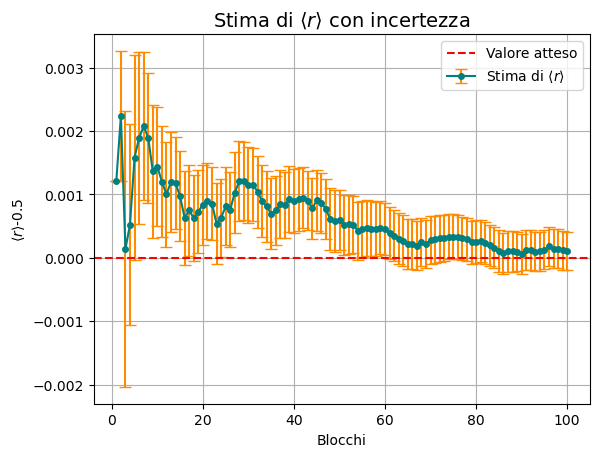

In [3]:
M=1000000
N=100
L=int(M/N)

# Grafico per valor medio di r
x, y = np.loadtxt('r_data.txt', unpack = True)

r = np.arange(N)

plt.errorbar(r+1,x-0.5, yerr=y, fmt='o-', color='teal', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label=r'Stima di $\langle r \rangle$')
plt.title(r"Stima di $\langle r \rangle$ con incertezza", fontsize=14)
plt.xlabel('Blocchi')
plt.ylabel(r'$\langle r \rangle$-0.5')
plt.axhline(0.0, color='red', linestyle='--', label = 'Valore atteso')
plt.grid(True)
plt.legend()
plt.show()




In figura è illustrato l'andamento della stima di $\langle r \rangle$, cui è stato sottratto il valore atteso di $0.5$. 

Possiamo osservare che la stima converge, con l'aumentare dei blocchi, al valore atteso, entro l'incertezza di $1\sigma$. Le forti variazioni iniziali sono smorzate all'aumentare del numero di blocchi, sintomo che il generatore di numeri casuali sta campionando una distribuzione uniforme. 

Per quanto riguarda l'incertezza associata, questa è settata a $0$ per il primo blocco, per il quale risulterebbe non calcolabile dato il suo andamento $\propto 1/\sqrt{N-1}$. Possiamo notare come nei primissimi blocchi, questa tenda a variare fortemente, anche incrementando (per esempio tra il secondo e il terzo blocco). Questo comportamento è dovuto alla scarsa quantità di dati a disposizione. All'aumentare del numero di blocchi, la decrescita dell'incertezza rallenta asintoticamente con $1/\sqrt{N-1}$.
Correttamente, il valore finale dell'incertezza risulta compatibile con l'errore teorico atteso, legato alla varianza del singolo lancio $\sigma^2 = 1/12$ (valutata nell'esercizio successivo): poiché ogni blocco è costituito dalla media di $L = 10^4$ lanci, l'incertezza associata al singolo blocco è proporzionale a $1/\sqrt{L}$. Componendo questo fattore con l'andamento sui blocchi, l'incertezza totale della simulazione scala approssimativamente come $1/\sqrt{L \cdot N}$, ovvero come $1/\sqrt{M}$, con $M$ numero totale di estrazioni.


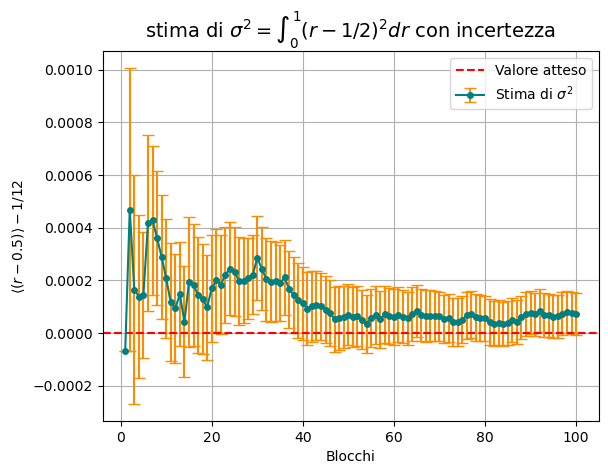

In [5]:
# Ripeto grafico per varianza di r
x, y = np.loadtxt('r_variance_data.txt', unpack = True)


plt.errorbar(r+1,x-1/12,yerr=y, fmt='o-', color='teal', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label=r'Stima di $\sigma^2$' )
plt.title(r"stima di $\sigma^2 = \int_0^1 (r-1/2)^2 dr$ con incertezza", fontsize = 14)
plt.xlabel('Blocchi')
plt.ylabel(r'$\langle (r-0.5) \rangle - 1/12$')
plt.axhline(0.0, color='red', linestyle='--', label = 'Valore atteso')
plt.grid(True)
plt.legend()
plt.show()


In figura è illustrato l'andamento della stima di $\sigma^2$, cui è stato sottratto il valore atteso di $1/12$. Anche in questo caso, le variazioni iniziali sono fortemente attenuate dall'aumentare del numero dei blocchi, e il valore medio di $\sigma^2$ converge a un valore costante compatibile con il valore atteso. L'incertezza decresce lentamente e appare quasi costante intorno agli ultimi blocchi.

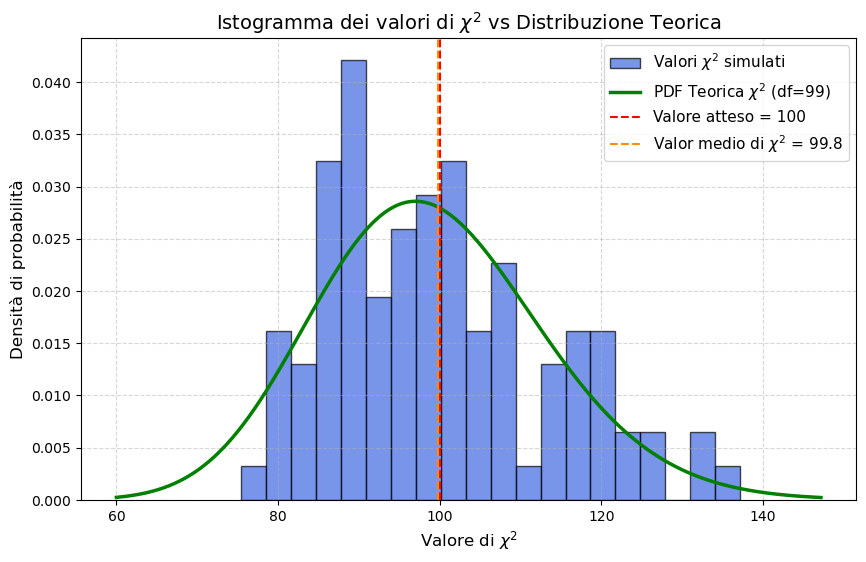

In [3]:
# Grafico del Chi quadro

chi_valori = np.loadtxt("Chisquare.txt")
media_chi = np.mean(chi_valori)

plt.figure(figsize=(10, 6))

plt.hist(chi_valori, bins=20, density=True, alpha=0.7, color='royalblue', edgecolor='black', label=r'Valori $\chi^2$ simulati')

df = 99 # Gradi di libertà

x_min = min(60, np.min(chi_valori) - 10)
x_max = max(140, np.max(chi_valori) + 10)
x = np.linspace(x_min, x_max, 500)

y = chi2.pdf(x, df)
plt.plot(x, y, 'g-', lw=2.5, label=rf'PDF Teorica $\chi^2$ (df={df})')

plt.title(r"Istogramma dei valori di $\chi^2$ vs Distribuzione Teorica", fontsize=14)
plt.xlabel(r"Valore di $\chi^2$", fontsize=12)
plt.ylabel("Densità di probabilità", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(100, color='red', linestyle='--', label = 'Valore atteso = 100')
plt.axvline(media_chi, color='darkorange', linestyle='--', label = rf'Valor medio di $\chi^2$ = {media_chi:.1f}')
plt.legend(fontsize=11)
plt.show()

Il $\chi^2$ è stato calcolato usando $n=10^6$ numeri casuali estratti sull'intervallo $[0, 1]$, diviso in $100$ sottointervalli.
Il test del $\chi^2$ sembrerebbe ampiamente superato, essendo il valore medio ottenuto molto prossimo a 100.

## <span style="color:blue">  Exercise 01.2 </span>

Nei grafici sottostanti sono rappresentate le distribuzioni ottenute con $10^4$ campioni di $S_N = \frac{1}{N}\sum_{i=1}^N x_i$, con $N=1, 2, 10, 100$ e $x_i$ una variabile casuale campionata lanciando un dado *standard*, un dado *esponenziale* ($\lambda=1$)e un dado *lorentziano* ($\mu=1$ e $\Gamma=3$).

In [32]:
from scipy.stats import norm, cauchy

In [109]:
def plot_distribution(data, title, is_cauchy=False):
    colors = ['steelblue', 'orange', 'green', 'red']
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    axes = axes.flatten() 
    
    for i in range(4):
        ax = axes[i]
        N = N_values[i]
        
        # Per la distribuzione di Cauchy, le code infinite rovinano l'istogramma.
        # Dobbiamo forzare un range fisso per riuscire a vedere la campana centrale.
        if is_cauchy:
            range_tuple = (-19, 21) 
        else:
            range_tuple = None
            
      
        if title.startswith("Dado"):
            # Distanza tra due possibili medie è 1/N
            delta = 1.0 / N
            
            min_val = np.min(data[i])
            max_val = np.max(data[i])
            
            # Creiamo un array di bordi distanziati esattamente di 'delta', 
            # spostati di delta/2 in modo che i valori possibili cadano al centro del bin
            custom_bins = np.arange(min_val - delta/2, max_val + delta/2 + delta, delta)
            
            ax.hist(data[i], bins=custom_bins, density=True, alpha=0.7, color=colors[i], edgecolor='black')
        else:
            # Per le distribuzioni continue usiamo 100 bin fissi
            ax.hist(data[i], bins=100, density=True, range=range_tuple, alpha=0.7, color=colors[i], edgecolor='black')
        
        # Fit teorico SOLO per il caso N=100 
        if N == 100:
            xmin, xmax = ax.get_xlim()
            x = np.linspace(xmin, xmax, 1000)
            
            if is_cauchy:
                # Fit con distribuzione di Cauchy
                loc, scale = cauchy.fit(data[i])
                p = cauchy.pdf(x, loc, scale)
                ax.plot(x, p, 'b-', linewidth=2.5, label='Fit Cauchy\n' + rf'$\mu={loc:.2f}, \Gamma={scale:.2f}$')
            else:
                # Fit con Gaussiana 
                mu, std = norm.fit(data[i])
                p = norm.pdf(x, mu, std)
                ax.plot(x, p, 'b-', linewidth=2.5, label='Fit Gaussiano\n' + rf'$\mu={mu:.2f}, \sigma={std:.2f}$')
            
            ax.legend(loc='upper right')
            
        ax.set_title(f"Medie di N = {N} estrazioni")
        ax.set_xlabel("Valore della media $S_N$")
        ax.set_ylabel("Densità")
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()


In [110]:
M = 10000
N_values = [1, 2, 50, 100]

dice_data = np.loadtxt("dice_averages.txt")
exp_data = np.loadtxt("exponential_averages.txt")
lorentz_data = np.loadtxt("lorentz_averages.txt")

dice_data = dice_data.reshape(4, M)
exp_data = exp_data.reshape(4, M)
lorentz_data = lorentz_data.reshape(4, M)

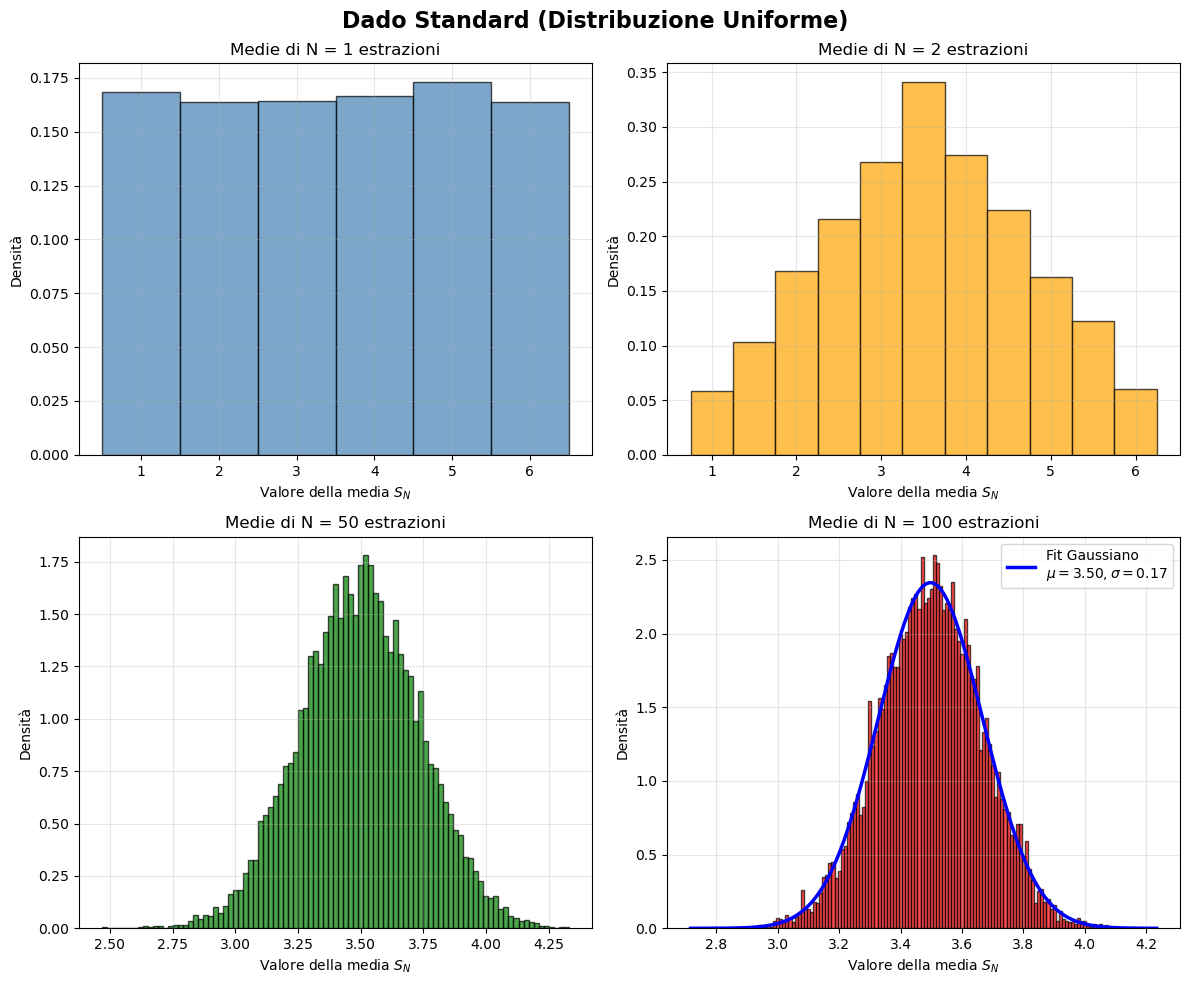

In [111]:
plot_distribution(dice_data, "Dado Standard (Distribuzione Uniforme)")

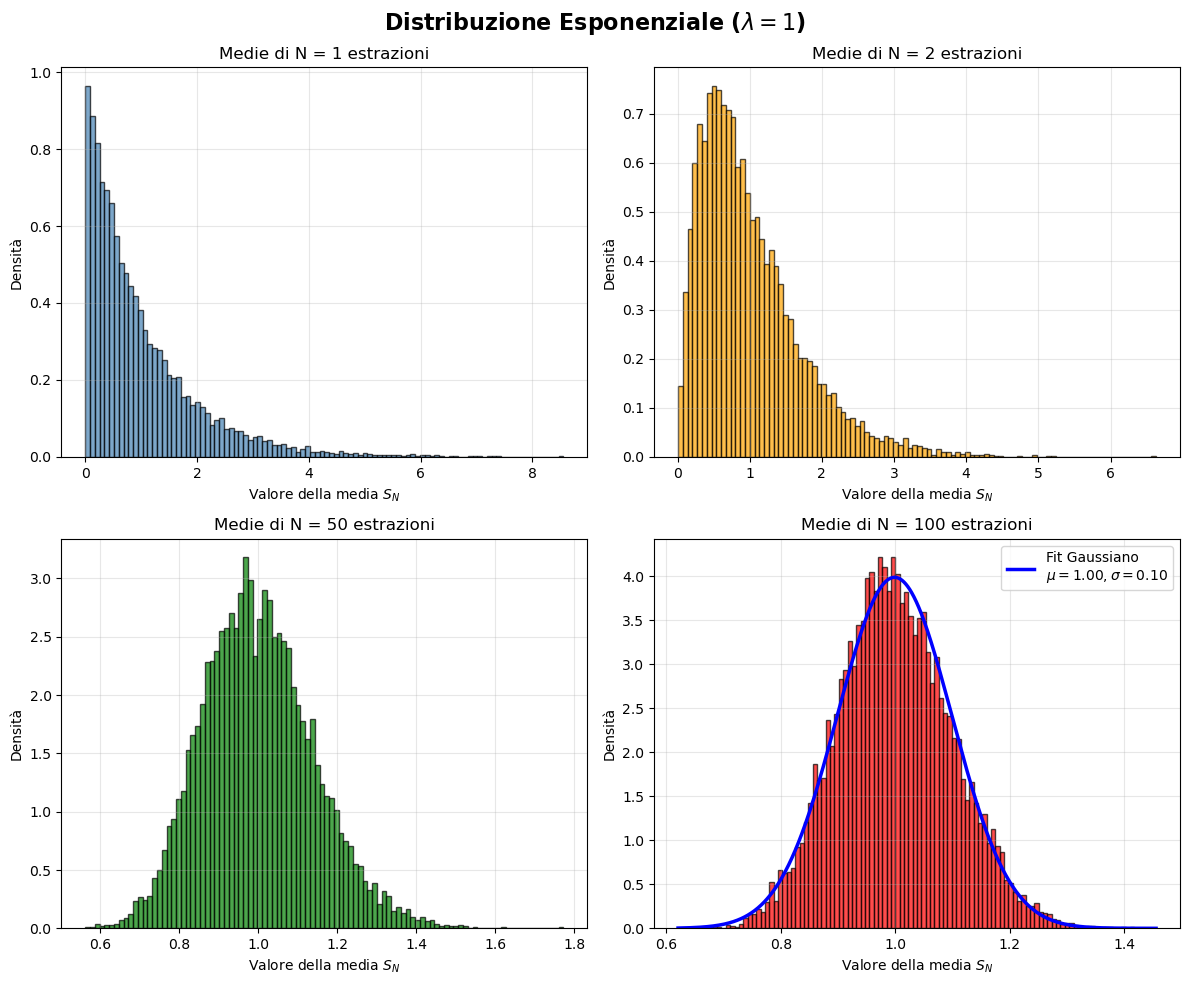

In [112]:
plot_distribution(exp_data, r"Distribuzione Esponenziale ($\lambda = 1$)")

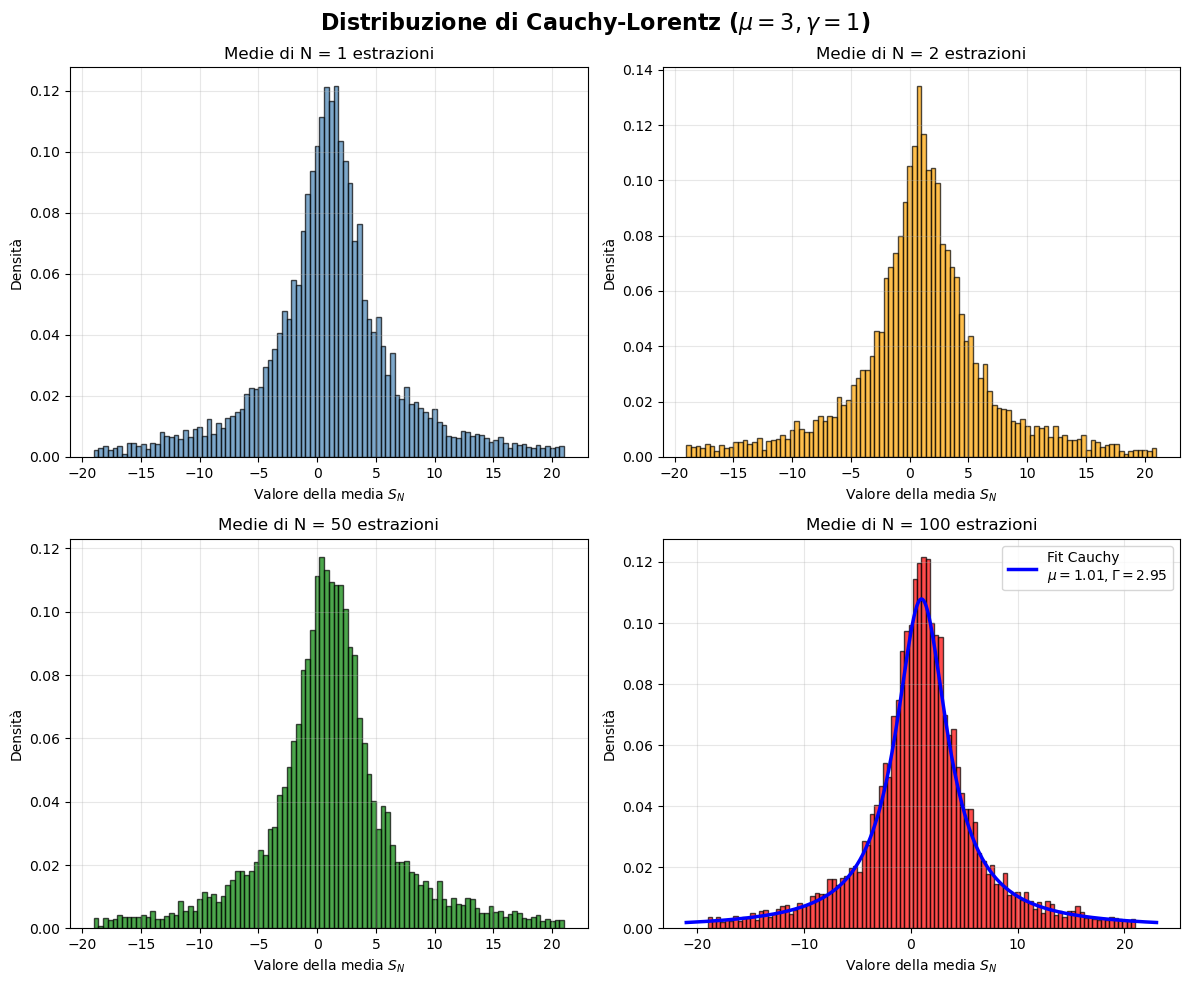

In [113]:
plot_distribution(lorentz_data, r"Distribuzione di Cauchy-Lorentz ($\mu = 3, \gamma = 1$)", is_cauchy=True)

Nelle immagini precdenti osserviamo come le distribuzioni di probabilità del dado uniforme, classico, e del dado esponenziale convergano per $N \rightarrow \infty$ a una distribuzione gaussiana. Questo avviene in accordo con il teorema del limite centrale, avendo queste due distribuzioni primo e secondo momento non divergenti. 

Nel caso del dado lorentziano, invece, questo segue una distribuzione di Cauchy che, per $x \rightarrow \infty$ presenta una coda di probabilità power-law del tipo $1/|x|^{\alpha +1}$, con $\alpha = 1$. Questa coda rende infinito il momento secondo della distribuzione, facendo cadere una delle ipotesi del teorema del limite centrale. La distribuzione di Cauchy-Lorentz, come la gaussiana, è stabile, ed è attrattore di sé stessa nello spazio delle distribuzioni di probabilità, in accordo con il teorema di Levy e Khintchine.

Ho imparato che la realtà è spesso gaussiana, ma non sempre...

## <span style="color:blue">  Exercise 01.3 </span>

Per svolgere l'esperimento di Buffon e stimare il valore di $\pi$, ho simulato il lancio di $M=10^6$ aghi di lunghezza $l=1$, su un pavimento intervallato da righe parallele distanziate di $d=1.2$. I lanci sono stati divisi in $N=100$ blocchi. 

Ogni volta che un ago interseca una delle linee orizzontali il numero $N_{hits}$ viene aggiornato. Alla fine di ogni blocco, composto di $N_{thr} = 100$, il valore di $\pi$ è stimato come $$\pi = \frac{2L}{Pd} = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d},$$ con $P = 2L/\pi d$ probabilità che un ago intersechi una linea.

Si è evitato di utilizzare, tautologicamente, $\pi$ per calcolare $\pi$ stesso. Per prima cosa si estratto casualmente ra $0$ e $d/2$ la posizione di atterraggio del punto medio dell'ago. A questo punto è necessario ottenere l'angolo di inclinazione $\theta$, per calcolare se $l*\sin(\theta)$ è maggiore o minore di $d/2$, e dunque se il lancio come come *hit* o meno. Si è dunque calcolato direttamente $\sin(\theta)$ generando due numeri casuali, assegnandone i valori a coordinate $x$ e $y$ in una semicirconferenza (si sarebbero potuti anche generare i due numeri in un quarto di circonferenza, data la simmetria della funzione seno. I due metodi sono computazionalmente identici): a questo punto si è calcolato $r^2 = x^2 + y^2$. Qualore $r^2>1$, il valore è stato scartato e l'estrazione ripetuta. In caso contrario, si è ottenuto il valore $\sin(\theta) = y/x$, sfruttando la trigonometria di base. 

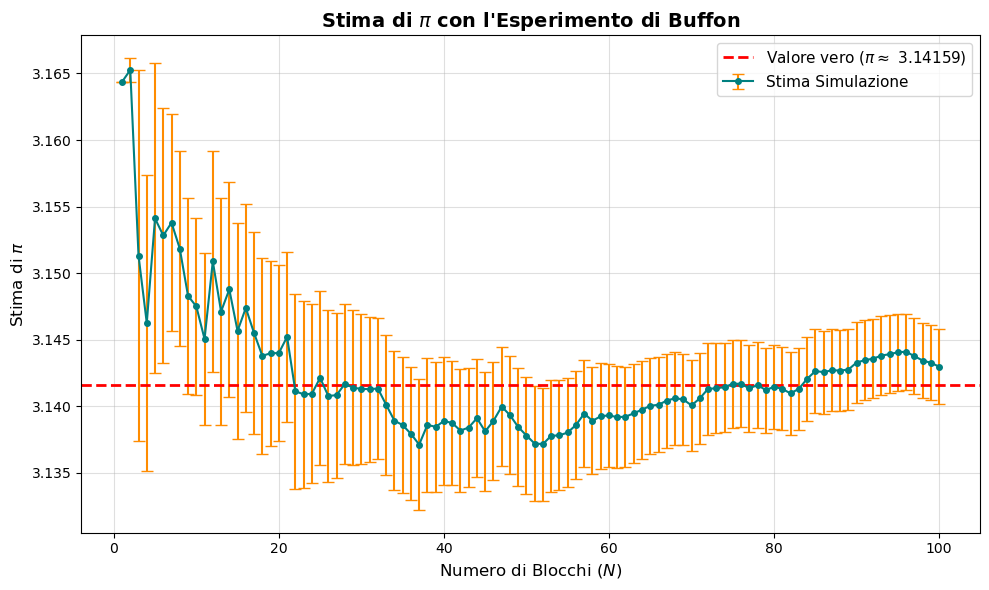

In [115]:

pi_prog, err_prog = np.loadtxt("pi_values.txt", usecols = (0,1), unpack = True)


N = len(pi_prog)
blocks = np.arange(1, N + 1)

plt.figure(figsize=(10, 6))

plt.errorbar(blocks, pi_prog, yerr=err_prog, fmt='o-', color='teal', 
             ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label='Stima Simulazione')

plt.axhline(y=np.pi, color='red', linestyle='--', linewidth=2, label=rf'Valore vero ($\pi \approx$ {np.pi:.5f})')


plt.title(r"Stima di $\pi$ con l'Esperimento di Buffon", fontsize=14, fontweight='bold')
plt.xlabel("Numero di Blocchi ($N$)", fontsize=12)
plt.ylabel(r"Stima di $\pi$", fontsize=12)
plt.grid(True, alpha=0.4)
plt.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()

Si può osservare come l'incertezza del secondo blocco sia estremamente (ed illusoriamente, poiché la media progressiva è ancora lontana dal valore di stabilizzazione così come dal valor vero) piccola: questo è dovuto al fatto che i valori medi dei primi due blocchi, casualmente, sono risultati molto vicini tra loro (lo testimonia anche il risibile spostamento della media progressiva). Questo dettaglio aiuta a rendersi conto dell'importanza di campionare la variabile in osservazione con un numero sufficiente di blocchi.